In [28]:
import numpy as np
import matplotlib.pyplot as plt

from block_encoding import generate_laplacian_block_encoding, get_circuit_unitary
from utils import prepare_v_vector, convert_vector_to_tensor

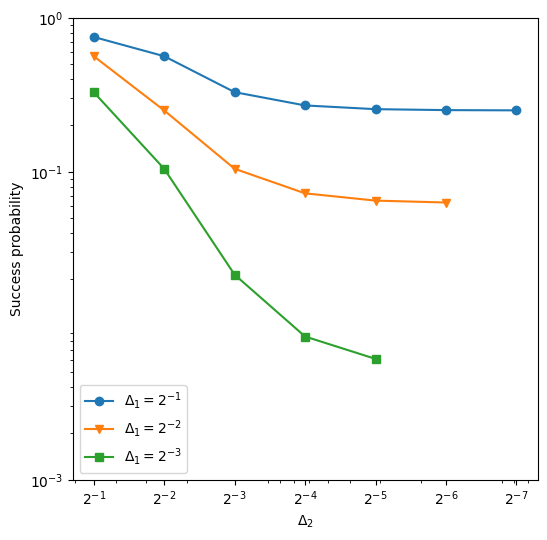

In [32]:
# Success probability vs (uneven) grid spacings
@np.vectorize
def v(x, y):
    return np.sin(2 * np.pi * (x + y))

nq1s = range(1, 4)

plt.figure(figsize=(6, 6))
markers = ["o", "v", "s"]

for i, nq1 in enumerate(nq1s):
    nq2s = range(1, 9 - nq1)

    deltas = [2**-nq for nq in nq2s]
    succ_probs = []

    for nq2 in nq2s:
        nqs = [nq1, nq2]
        nqs = [nq1, nq2]
        v_vec = prepare_v_vector(nqs, v)
        qc = generate_laplacian_block_encoding(nqs, bcs=["periodic", "periodic"], vs=v_vec)
        unitary = get_circuit_unitary(qc, nqs)
        succ_probs.append(np.linalg.norm(unitary[:, 0]) ** 2)

    plt.plot(deltas, succ_probs, marker=markers[i], label=f"$\\Delta_1 = 2^{{{-nq1}}}$")

plt.xscale("log")
plt.xticks([2**-i for i in range(1, 8)])
plt.xlabel("$\\Delta_2$")
plt.gca().set_xticklabels([f"$2^{{-{i}}}$" for i in range(1, 8)])
plt.gca().invert_xaxis()

plt.yscale("log")
plt.yticks([1] + [10**i for i in range(-3, 0, 2)])
plt.ylabel("Success probability")

plt.legend()
plt.show()


In [33]:
# Number of 2 qubit gates when circuit is transpiled with Heron basis gates set